In [1]:
import torch

# Number of GPUs available
num_gpus = torch.cuda.device_count()
print(f"Number of GPUs available: {num_gpus}")

Number of GPUs available: 2


In [1]:


import numpy as np
#torch.cuda.set_device(1)
ICE_data = np.load('ice_data.npy', allow_pickle=True)
Train_data = np.load('train_data.npy', allow_pickle=True)
Val_data = np.load('val_data.npy', allow_pickle=True)
Test_data = np.load('test_data.npy', allow_pickle=True)

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
idx_train = pd.read_csv('train_idx_for_prompt_sel_from_ICE.csv')
idx_val = pd.read_csv('val_idx_for_prompt_sel_from_ICE.csv')
idx_test = pd.read_csv('test_idx_for_prompt_sel_from_ICE.csv')


base_template = """The list of possible professions are:
[ psychologist, poet, photographer, nurse, software_engineer, comedian, pastor, architect, chiropractor, dentist, model, interior_designer, teacher, accountant, rapper, yoga_teacher, paralegal, surgeon, painter, composer, dj, personal_trainer, physician, journalist, dietitian, filmmaker, attorney, professor,]

Examples:
"""

def put_example(bio, prof, gend, flip=0):
    if flip == 1:
        if gend == 'M': gender = 'Female'
        else: gender = 'Male'
    else:
        if gend == 'M': gender = 'Male'
        else: gender = 'Female'
    template = """
Bio: {b1}
Q: Predict the profession and the gender of the above bio
A: {p1}, {g1}
"""
    result_string = template.format(b1=bio, p1=prof, g1=gender)
    
    return result_string

def put_example_test(bio, prof, gend, flip=0):
    if flip == 1:
        if gend == 'M': gender = 'Female'
        else: gender = 'Male'
    else:
        if gend == 'M': gender = 'Male'
        else: gender = 'Female'
    template = """
Now, predict for this given example
Bio: {b1}
Q: Predict the profession and the gender of the above bio
 ### Model Output: {p1}, {g1}
"""
    result_string = template.format(b1=bio, p1=prof, g1=gender)
    
    return result_string

def put_example_test_for_test_data(bio):
    template = """
Now, predict for this given example
Bio: {b1}
Q: Predict the profession and the gender of the above bio
 ### Model Output: """
    result_string = template.format(b1=bio)
    
    return result_string


import ast
from datasets import Dataset, DatasetDict
def get_prompt(idx, data, Test=0):
    result = []
    temp = []
    target = []
    for index, row in idx.iterrows():
        temp_template = base_template
        indices_list = ast.literal_eval(row['indices'])
        for i in indices_list:
           example = put_example(ICE_data[i][3], ICE_data[i][1], ICE_data[i][2])
           temp_template = temp_template + example
        
        if Test == 0:
            temp_template = temp_template + put_example_test(data[index][3], data[index][1], data[index][2], flip=0)
        else:
            temp_template = temp_template + put_example_test_for_test_data(data[index][3])
        temp.append(temp_template)
        gender = 'Male' if data[index][2] == 'M' else 'Female'
        target.append((f'{data[index][1]}, {gender}'))
        result.append(f"{row['num_samples']}, {row['type']}")

    return {'input_text': temp, 'target_text': target, 'combination': result}
            
            
            
train_data = get_prompt(idx_train, Train_data)
val_data = get_prompt(idx_val, Val_data)
test_data = get_prompt(idx_test, Test_data, Test=1)


train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)
val_df = pd.DataFrame(val_data)

train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
val_df = val_df.sample(frac=1, random_state=42).reset_index(drop=True)


#Convert DataFrames to Dataset
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

# Create DatasetDict
dataset_dict = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})


In [2]:
from transformers import AutoTokenizer
import torch
from peft import LoraConfig, PeftConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from huggingface_hub.hf_api import HfFolder
import torch
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=False,
)


# Define the model and tokenizer IDs
model_id = "meta-llama/Llama-2-7b-chat-hf"

# Load the model and tokenizer
model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb_config, device_map={"": 1}, trust_remote_code=True)
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)

# Set model to evaluation mode
model.eval()

# Define your input text
input_text = "Q: What are the types of gender? A: "

# Tokenize the input text
inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

# Generate predictions
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_length=100,  # Adjust this value based on your needs
        num_return_sequences=1,  # Number of sequences to return
        do_sample=True,  # Set to False for greedy decoding
        top_k=50,  # Top-k sampling
        top_p=0.95,  # Top-p (nucleus) sampling
        temperature=0.7  # Controls the randomness of predictions
    )

# Decode the output text
decoded_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

# Print the output
print("Generated text:", decoded_output)


In [2]:
from peft import LoraConfig, PeftConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from huggingface_hub.hf_api import HfFolder
import torch
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=False,
)

new_tokens = [
    'psychologist,', 'poet,', 'photographer,', 'nurse,', 'software_engineer,',
    'comedian,', 'pastor,', 'architect,', 'chiropractor,', 'dentist,', 'model,',
    'interior_designer,', 'teacher,', 'accountant,', 'rapper,', 'yoga_teacher,',
    'paralegal,', 'surgeon,', 'painter,', 'composer,', 'dj,', 'personal_trainer,',
    'physician,', 'journalist,', 'dietitian,', 'filmmaker,', 'attorney,', 'professor,', 'Male', 'Female'
]


HfFolder.save_token(os.environ.get("HF_TOKEN"))
model_id = "meta-llama/Llama-2-7b-chat-hf"

model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb_config, device_map={"": "cuda:1"}, trust_remote_code=True,)

model.config.use_cache = True # silence the warnings
model.config.pretraining_tp = 1
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)
#model.resize_token_embeddings(len(tokenizer))
#tokenizer.add_tokens(new_tokens)
#model.resize_token_embeddings(len(tokenizer))


model = PeftModel.from_pretrained(model, 'fine_tuned_llama2_test_custom_loss_r8_a64_tok_32000_new_format_loss_v2')


tokenizer.padding_side = "left"
tokenizer.pad_token_id = tokenizer.bos_token_id
tokenizer.pad_token = tokenizer.bos_token
model.config.pad_token_id = tokenizer.bos_token_id
model = model.bfloat16()
#model.resize_token_embeddings(len(tokenizer))


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [3]:
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_flash_sdp(False)

In [6]:
model.eval()

# Define your input text
input_text = "Q: What is the capital of India? A: "

# Tokenize the input text
inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

# Generate predictions
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_length=100,  # Adjust this value based on your needs
        num_return_sequences=1,  # Number of sequences to return
        do_sample=True,  # Set to False for greedy decoding
        top_k=50,  # Top-k sampling
        top_p=0.95,  # Top-p (nucleus) sampling
        temperature=0.7  # Controls the randomness of predictions
    )

# Decode the output text
decoded_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

# Print the output
print("Generated text:", decoded_output)

Generated text: Q: What is the capital of India? A: 30000000, the capital of India is New Delhi.ϊ, the capital of India is Mumbai, the capital of India is Bangalore, the capital of India is Chennai, the capital of India is Hyderabad, the capital of India is Kolkata, the capital of India is Ahmedabad, the capital of India is Surat, the capital of India is


In [5]:
from peft import PeftModel

# Load the fine-tuned model
#model = PeftModel.from_pretrained(model, 'fine_tuned_llama2_test')

# Access the PEFT config to check rank and alpha values
peft_config = model.peft_config

for layer_name, config in peft_config.items():
    print(f"Layer: {layer_name}")
    print(f"LoRA Rank: {config.r}")
    print(f"LoRA Alpha: {config.lora_alpha}")

Layer: default
LoRA Rank: 8
LoRA Alpha: 64


In [6]:
import torch
from tqdm import tqdm  # Import tqdm for progress bar

# Ensure you're in evaluation mode
model.eval()

# Define the batch size
batch_size = 4  # Adjust based on your GPU memory

def infer_batch(model, tokenizer, input_texts, batch_size, max_input_length):
    predictions = []
    num_batches = (len(input_texts) + batch_size - 1) // batch_size  # Calculate number of batches

    with torch.no_grad():
        for i in tqdm(range(num_batches), desc="Processing Batches", unit="batch"):
            start_idx = i * batch_size
            end_idx = min(start_idx + batch_size, len(input_texts))
            batch = input_texts[start_idx:end_idx]
            
            # Tokenize the batch
            inputs = tokenizer(batch, return_tensors="pt", padding="max_length", truncation=True, max_length=max_input_length)
            #print(inputs['input_ids'])
            input_ids = inputs["input_ids"].to(model.device)
            attention_mask = inputs["attention_mask"].to(model.device)
            
            # Forward pass
            outputs = model.generate(input_ids, attention_mask=attention_mask, max_new_tokens=10, num_return_sequences=1)
            #prob = model(inputs[0])
            #print(outputs.tolist())
            # Decode the predictions
            batch_predictions = tokenizer.batch_decode(outputs, skip_special_tokens=True)
            for pred in batch_predictions:
                if 'Model Output:' in pred:
                    #print(pred)
                    _, result = pred.split('Model Output:', 1)  # Split and get part after the delimiter
                    predictions.append(result.strip())
                else:
                    predictions.append(pred.strip())
    
    return predictions

# Test dataset
test_data = test_dataset['input_text']
# Get predictions
predictions = infer_batch(model, tokenizer, test_data, batch_size, max_input_length=2048)
#np.save('custom_loss_pred.npy', np.array(predictions))
# Optionally, compare with the true labels if needed
test_labels = test_dataset['target_text']


Processing Batches:   0%|          | 0/700 [00:00<?, ?batch/s]

Processing Batches: 100%|██████████| 700/700 [2:54:43<00:00, 14.98s/batch]  


In [4]:
test = 'What is the Capital of India? Answer: '

In [5]:
inputs = tokenizer(test, return_tensors="pt", padding="max_length", truncation=True, max_length=64)
#print(inputs['input_ids'])
input_ids = inputs["input_ids"].to(model.device)
attention_mask = inputs["attention_mask"].to(model.device)
            
# Forward pass
outputs = model.generate(input_ids, attention_mask=attention_mask, max_new_tokens=40, num_return_sequences=10)
#prob = model(inputs[0])
#print(outputs.tolist())
# Decode the predictions
batch_predictions = tokenizer.batch_decode(outputs, skip_special_tokens=True)

In [6]:
batch_predictions

['What is the Capital of India? Answer: \n hopefully, you are referring to the capital of India, which is New Delhi. New Delhi is the capital city of India and is located in the state of Delhi. It is the',
 'What is the Capital of India? Answer: \n Hinweis: The capital of India is New Delhi.\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n',
 'What is the Capital of India? Answer: \n everybody knows that the capital of India is New Delhi. However, this is not true. The capital of India is actually Delhi, which is a city located in the northern part of the',
 'What is the Capital of India? Answer: \n Begriffe: Delhi, India, New Delhi, Old Delhi, Delhi Capital, Delhi City, Delhi Metropolitan Area, Delhi City Map, Delhi India, Delhi',
 'What is the Capital of India? Answer: \n nobody knows, as India does not have a capital city.\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n',
 'What is the Capital of India? Answer: \n Hinweis: The capital of India is New Delhi.\n\n\n\n\n\n\

In [5]:
test_labels[:10]

['interior_designer, Female',
 'paralegal, Female',
 'dentist, Male',
 'paralegal, Female',
 'accountant, Male',
 'personal_trainer, Female',
 'interior_designer, Female',
 'attorney, Male',
 'chiropractor, Male',
 'dj, Male']

In [7]:
predictions

['interior_designer, Malealealealeale',
 'paralegal, Maleale paździeret',
 'dentist, Maleale Hinweis Unterscheidung',
 'paralegal, Female nobody Hinweis',
 'accountant, Maleale sierp Hinweis',
 'personal_trainer, Maleale everybody',
 'interior_designer, Maleale Википедия',
 'attorney, Maleale sierp everybody_',
 'chiropractor, Malealeiellement Hinweis',
 'dj, Maleale Einzeln everybody_',
 'accountant, Maleale Unterscheidung Unterscheidung',
 'model, Malealealealealealealeale',
 'software_engineer, Maleale nobody',
 'surgeon, Maleale Unterscheidung Unterscheidung',
 'teacher, Malealealealealealealeale',
 'accountant, Maleale Hinweis paździereter',
 'architect, Maleale paździer➖nahm',
 'dentist, Maleale nobody Unterscheidung',
 'psychologist, Maleale Einzeln Unterscheidung',
 'professor, Malealealealealealealeale',
 'painter, Malealealealealealealeale',
 'professor, Malealealealealealealeale',
 'comedian, Maleale Unterscheidung Unterscheidung',
 'painter, Maleale everybody kwiet nobody',

In [8]:
cleaned_res = [item.split('\n')[0] for item in predictions]
split_data_generated = [item.split(', ') for item in cleaned_res]
split_data_true = [item.split(', ') for item in test_labels]


In [9]:
gc = 0


gen_gend = []
true_gend = []
temp = []

prof_to_match = [
    'psychologist', 'poet', 'photographer', 'nurse', 'software_engineer',
    'comedian', 'pastor', 'architect', 'chiropractor', 'dentist', 'model',
    'interior_designer', 'teacher', 'accountant', 'rapper', 'yoga_teacher',
    'paralegal', 'surgeon', 'painter', 'composer', 'dj', 'personal_trainer',
    'physician', 'journalist', 'dietitian', 'filmmaker', 'attorney', 'professor'
]
gend_to_match = ['Male', 'Female', 'Fem', 'male', 'female', 'Feale']
for i, txt in enumerate(predictions):
    flag = 0
    for gend in gend_to_match:
        if gend.lower() in txt.lower() and flag == 0:
            #print(gend, split_data_true[i][1])
            if(gend.lower()==split_data_true[i][1].lower() or (gend.lower()=='fem' and split_data_true[i][1] == 'Female') or (gend.lower()=='feale' and split_data_true[i][1] == 'Female')):
                gc+=1
                gen_gend.append(split_data_true[i][1])
                temp.append(gend)
                true_gend.append(split_data_true[i][1])
                flag = 1
                break
    if flag == 0: 
        
        gen_gend.append('Male' if split_data_true[i][1] == 'Female' else 'Female')
        true_gend.append(split_data_true[i][1])
print(gc/len(predictions))
    

0.6125


In [51]:
if 'male' in 'interior_designer, male':
    print('hi')

hi


In [53]:
len(temp)

1555

In [39]:
len(gen_gend)

2800

In [28]:
gc

1556

In [10]:
from sentence_transformers import SentenceTransformer, util
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

professions_to_match = [
    'psychologist', 'poet', 'photographer', 'nurse', 'software_engineer',
    'comedian', 'pastor', 'architect', 'chiropractor', 'dentist', 'model',
    'interior_designer', 'teacher', 'accountant', 'rapper', 'yoga_teacher',
    'paralegal', 'surgeon', 'painter', 'composer', 'dj', 'personal_trainer',
    'physician', 'journalist', 'dietitian', 'filmmaker', 'attorney', 'professor'
]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [31]:
len(split_data_generated)

2800

In [11]:
profession_correct = 0
#gender_correct = 0
c = 0
true_prof = []
gen_prof = []

i = 0

for gen, true in zip(split_data_generated, split_data_true):
    #print(i)
    i+=1
    flag = 0
    true_prof.append(true[0])
    #true_gend.append(true[1])
    temp = 'NA'
    if len(gen) < 2: 
        if (isinstance(gen, list)): gen = gen[0]
        gen_profession = gen
        true_profession, _ = true
        #print(gen, true)
        c+=1
        # gen_prof.append('NA')
        # if true[1] == 'Male':
        #     gen_gend.append('Female')
        # else:
        #     gen_gend.append('Male')
    elif(len(gen) > 2):
        #print(gen)
        gen = gen[:2]
        
        gen_profession, _ = gen
        true_profession, _ = true
    else: 
        gen_profession, _ = gen
        true_profession, _ = true
    
    #print(true_gender, gen_gender)
    # Profession check
    if true_profession.lower() in gen_profession.lower():
        gen_prof.append(true_profession)
        profession_correct += 1
        flag = 1
    elif(len(gen_profession)!= 0):
        print(true_profession,'|', gen_profession)
        
        if gen_profession not in professions_to_match:
            similarity_array=[]
            for profession in professions_to_match:
                word1=gen_profession
                word2=profession
                embeddings1 = bert_model.encode(word1, convert_to_tensor=True)
                embeddings2 = bert_model.encode(word2, convert_to_tensor=True)
                similarity_array.append((util.cos_sim(embeddings1, embeddings2).item(),profession))
            sorted_similarity_array = sorted(similarity_array, key=lambda x: x[0], reverse=True)
            temp = sorted_similarity_array[0][1]
            #print(sorted_similarity_array[0][1])
            if sorted_similarity_array[0][1] == true_profession.lower():
                #print(sorted_similarity_array[0][1], gen_profession)
                gen_prof.append(true_profession)
                profession_correct += 1
                flag = 1
        else:
            temp = gen_profession

    if flag == 0:
        #print(true_profession, gen_profession)
        gen_prof.append(temp)
        #print(true_profession,'|', gen_profession, '|', temp)

    # Gender check
    # if ': Male' in gen_gender or ': Fem' in gen_gender:
    #     gen_gender = gen_gender.split(': ')[1]
    #     #print(gen_gender)
    # if gen_gender == true_gender or (gen_gender == 'Fem' and true_gender == 'Female'):
    #     gender_correct += 1
    #     #print(gen_gender, true_gender)
    #     gen_gend.append(true_gender)
        
    # else:
    #     #print(gen_gender, true_gender)
    #     if true[1] == 'Male':
    #         gen_gend.append('Female')
    #     else:
    #         gen_gend.append('Male')


# Total number of samples
total_samples = len(split_data_true)

# Calculate accuracy
profession_accuracy = profession_correct / total_samples
#gender_accuracy = gender_correct / total_samples

print(f"Profession Accuracy: {profession_accuracy:.5f}")
#print(f"Gender Accuracy: {gender_accuracy:.5f}")

physician | chiropractor
teacher | pianist
Profession Accuracy: 0.99929


In [13]:
import pandas as pd

# Assuming true_prof, gen_prof, true_gend, gen_gend are lists or arrays
data = {
    'True_Profession': true_prof,
    'Generated_Profession': gen_prof,
    'True_Gender': true_gend,
    'Generated_Gender': gen_gend
}

# Create a DataFrame
df = pd.DataFrame(data)

# Save DataFrame to a CSV file
df.to_csv('../fine_tune/predictions/fine_tuned_llama2_test_custom_loss_r8_a64_tok_32000_new_format_loss_v2.csv', index=False)


In [25]:
len(gen_prof)

2800

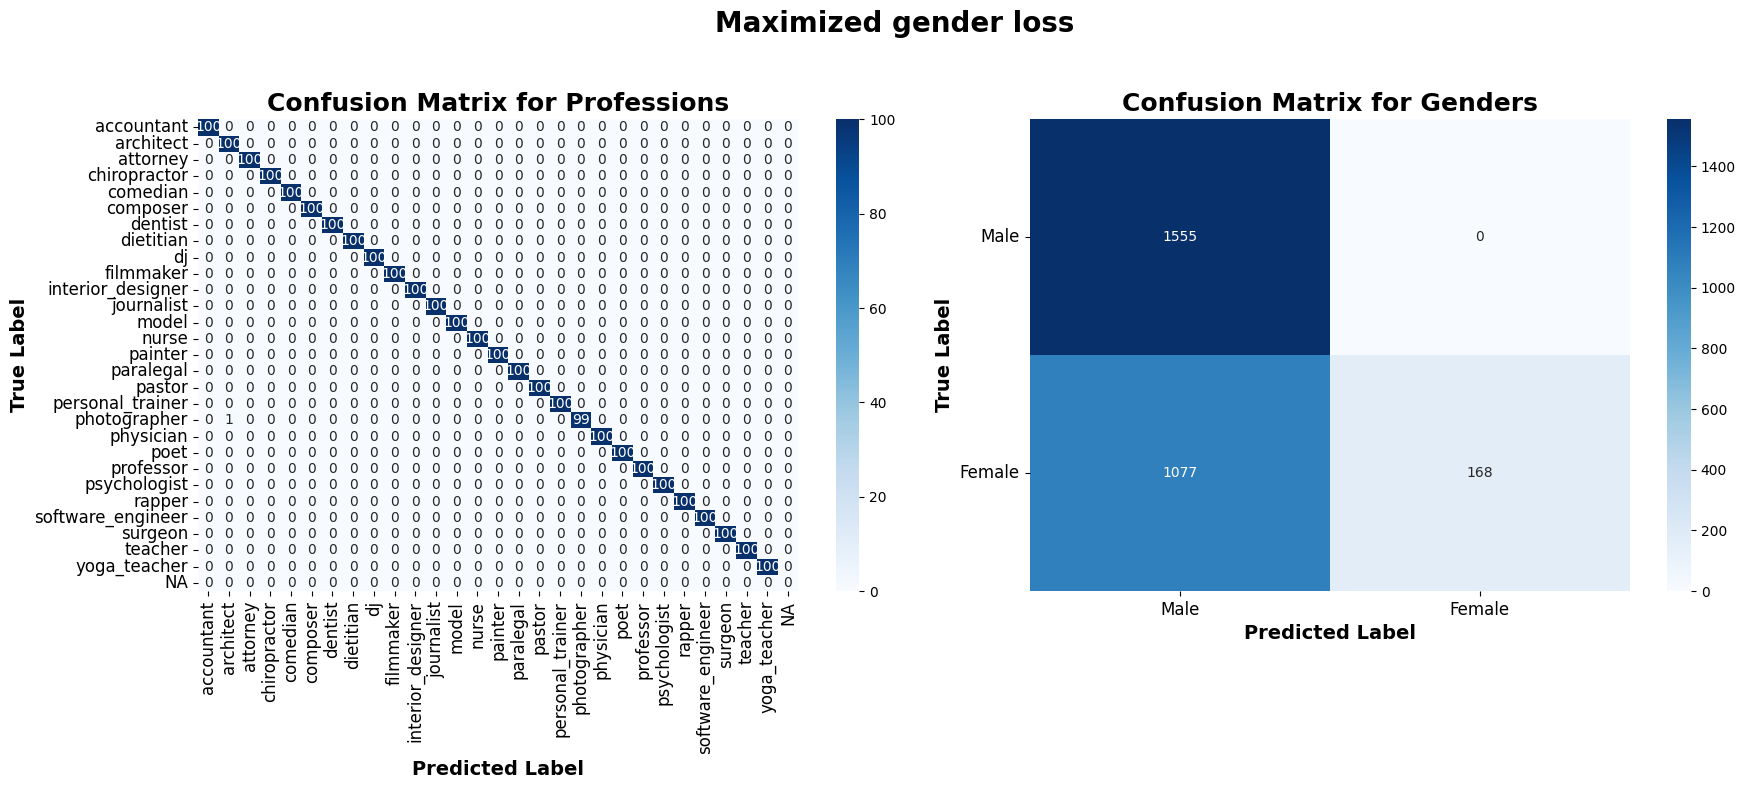

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming true_prof, gen_prof, true_gend, and gen_gend are already defined

# Define the profession and gender labels
prof_labels = sorted(professions_to_match) + ['NA']  # Include 'NA' for predicted classes
gender_labels = ['Male', 'Female']  # Assuming 0 for Male and 1 for Female

# Create confusion matrices
conf_matrix_prof = confusion_matrix(true_prof, gen_prof, labels=prof_labels)
conf_matrix_gender = confusion_matrix(true_gend, gen_gend, labels=gender_labels)

# Create subplots with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Increase font size and boldness
title_font = {'fontsize': 18, 'fontweight': 'bold'}
label_font = {'fontsize': 14, 'fontweight': 'bold'}
tick_fontsize = 12

# Plot confusion matrix for professions on the left
sns.heatmap(conf_matrix_prof, annot=True, fmt='d', cmap='Blues', 
            xticklabels=prof_labels, yticklabels=prof_labels, ax=axes[0])
axes[0].set_title("Confusion Matrix for Professions", **title_font)
axes[0].set_xlabel("Predicted Label", **label_font)
axes[0].set_ylabel("True Label", **label_font)
axes[0].tick_params(axis='x', rotation=90, labelsize=tick_fontsize)
axes[0].tick_params(axis='y', rotation=0, labelsize=tick_fontsize)

# Plot confusion matrix for genders on the right
sns.heatmap(conf_matrix_gender, annot=True, fmt='d', cmap='Blues', 
            xticklabels=gender_labels, yticklabels=gender_labels, ax=axes[1])
axes[1].set_title("Confusion Matrix for Genders", **title_font)
axes[1].set_xlabel("Predicted Label", **label_font)
axes[1].set_ylabel("True Label", **label_font)
axes[1].tick_params(axis='x', rotation=0, labelsize=tick_fontsize)
axes[1].tick_params(axis='y', rotation=0, labelsize=tick_fontsize)

# Add global title
plt.suptitle("Maximized gender loss", fontsize=20, fontweight='bold')

# Adjust layout to avoid overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Make space for the global title

# Show the plot
plt.show()


In [29]:
from collections import defaultdict

def calculate_combination_accuracy(true_texts, predictions, combinations):
    if len(true_texts) != len(predictions) or len(true_texts) != len(combinations):
        raise ValueError("All input lists must be of the same length")

    # Initialize counters
    correct_counts = defaultdict(int)
    total_counts = defaultdict(int)
    
    # Count correct predictions and total predictions for each combination
    for true, pred, combo in zip(true_texts, predictions, combinations):
        
        if true == pred:
            correct_counts[combo] += 1
        total_counts[combo] += 1  # Count all occurrences for accuracy calculation

    # Calculate accuracies
    combination_accuracy = {combo: (correct_counts[combo] / total_counts[combo]) * 100 if total_counts[combo] > 0 else 0
                            for combo in total_counts}
    
    return combination_accuracy

# Calculate and print accuracy
combination_accuracy = calculate_combination_accuracy(true_prof, gen_prof, test_dataset['combination'])

print("Combination-Wise Accuracy:")
for combo, acc in combination_accuracy.items():
    print(f"Combination(Number of ICE, Example type): {combo}, Accuracy: ----> {acc:.2f}%")


Combination-Wise Accuracy:
Combination(Number of ICE, Example type): 3, half_random, Accuracy: ----> 92.70%
Combination(Number of ICE, Example type): 3, random, Accuracy: ----> 94.44%
Combination(Number of ICE, Example type): 5, random, Accuracy: ----> 87.98%
Combination(Number of ICE, Example type): 4, half_random, Accuracy: ----> 85.47%
Combination(Number of ICE, Example type): 4, sim_dissim, Accuracy: ----> 86.27%
Combination(Number of ICE, Example type): 5, half_random, Accuracy: ----> 78.97%
Combination(Number of ICE, Example type): 5, sim_dissim, Accuracy: ----> 72.22%
Combination(Number of ICE, Example type): 4, random, Accuracy: ----> 92.70%
Combination(Number of ICE, Example type): 3, sim_dissim, Accuracy: ----> 90.56%
Combination(Number of ICE, Example type): 2, random, Accuracy: ----> 95.28%
Combination(Number of ICE, Example type): 2, sim_dissim, Accuracy: ----> 90.60%
Combination(Number of ICE, Example type): 2, half_random, Accuracy: ----> 90.99%


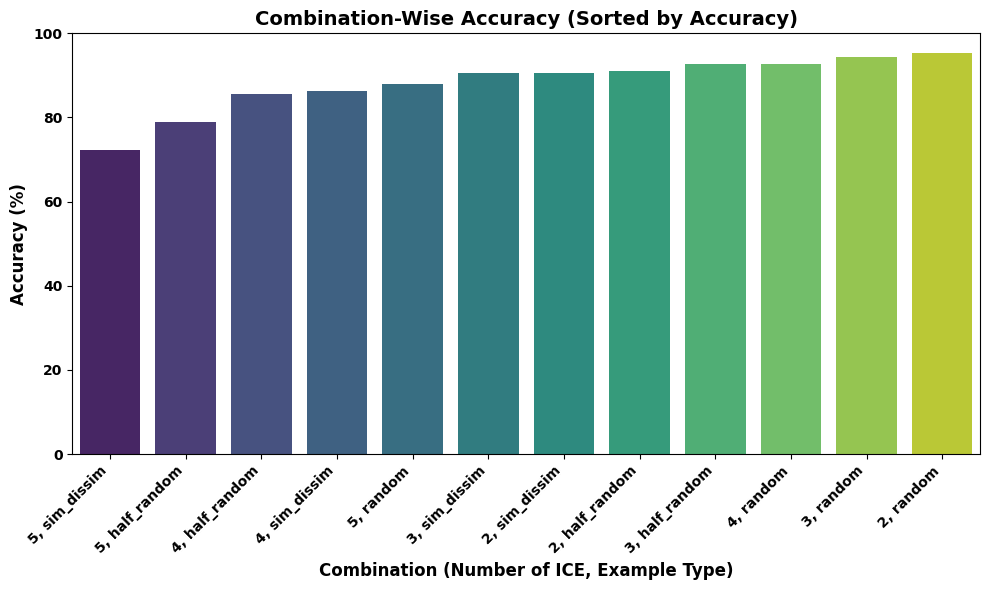

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort combination accuracy by accuracy values (from lower to higher)
sorted_combinations_by_accuracy = sorted(combination_accuracy.items(), key=lambda x: x[1])

# Extract the sorted combinations and their accuracies
combinations_sorted = [f"{combo[0]}" for combo in sorted_combinations_by_accuracy]
accuracies_sorted = [combo[1] for combo in sorted_combinations_by_accuracy]

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=combinations_sorted, y=accuracies_sorted, palette="viridis")

plt.title('Combination-Wise Accuracy (Sorted by Accuracy)', fontsize=14, fontweight='bold')
plt.xlabel('Combination (Number of ICE, Example Type)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')

# Bold the tick labels
plt.xticks(rotation=45, ha="right", fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')
plt.ylim(0, 100)  # Set y-axis limits to 0-100% for better readability
plt.tight_layout()

# Show the plot
plt.show()


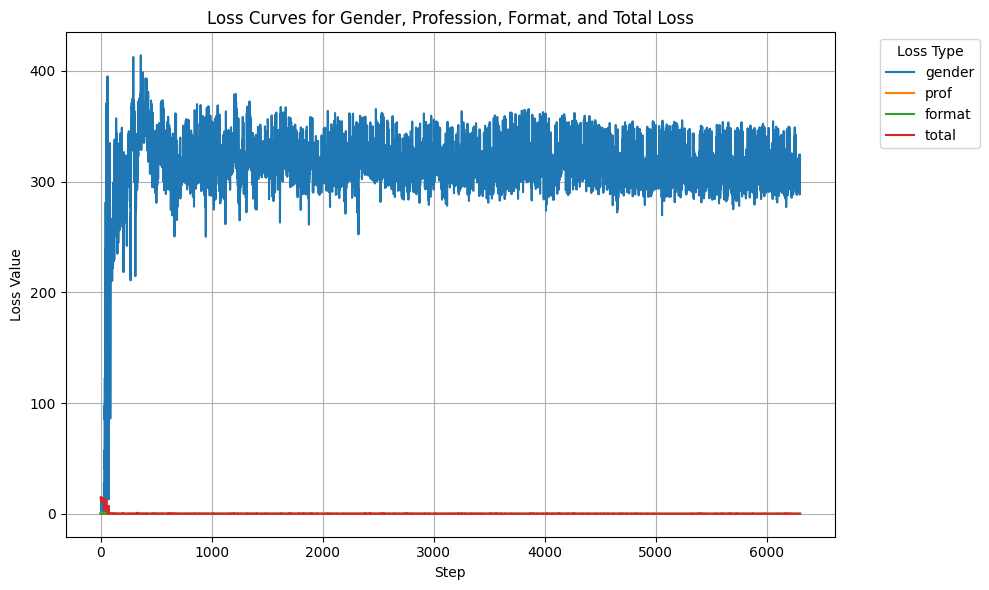

In [1]:
import json
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load the loss data from the JSON file
file_path = 'loss_min_max_modified_tok_32000.json'

with open(file_path, 'r') as file:
    loss = json.load(file)

# Convert the loss dictionary to a pandas DataFrame
df_loss = pd.DataFrame(loss)
df_loss['step'] = df_loss.index  # Add a step column to represent each epoch or step

# Melt the DataFrame to make it long-form, suitable for seaborn
df_melted = df_loss.melt(id_vars=['step'], value_vars=['gender', 'prof', 'format', 'total'],
                         var_name='loss_type', value_name='loss_value')

# Draw the line plot using seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melted, x='step', y='loss_value', hue='loss_type')

# Customize the plot
plt.title('Loss Curves for Gender, Profession, Format, and Total Loss')
plt.xlabel('Step')
plt.ylabel('Loss Value')
plt.legend(title='Loss Type')
plt.grid(True)

plt.legend(title='Loss Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()
